In [12]:
# =============================================================================
# SOCIAL ENGINEERING EMAIL DETECTION SYSTEM (Phishing + BEC + Fraud)
# Full Implementation in One Notebook
# Targeted for Nigeria & Africa users
# =============================================================================

import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Create folder structure if not exists
folders = ['data/raw', 'data/processed', 'models', 'reports']
for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("✅ Folder structure ready!")

✅ Folder structure ready!


In [13]:
# Install opendatasets if needed (run once)
!pip install opendatasets kagglehub -q

import opendatasets as od

# Download all 4 Kaggle datasets automatically
datasets = [
    "https://www.kaggle.com/datasets/rtatman/fraudulent-email-corpus",
    "https://www.kaggle.com/datasets/yoadjei/adversarial-bec-email-dataset",
    "https://www.kaggle.com/datasets/naserabdullahalam/phishing-email-dataset",
    "https://www.kaggle.com/datasets/kuladeep19/phishing-and-legitimate-emails-dataset"
]

for dataset in datasets:
    print(f"Downloading {dataset.split('/')[-1]}...")
    od.download(dataset, data_dir='data/raw')
    
print("\n✅ All datasets downloaded!")

Skipping, found downloaded files in "data/raw\fraudulent-email-corpus" (use force=True to force download)
Skipping, found downloaded files in "data/raw\adversarial-bec-email-dataset" (use force=True to force download)
Skipping, found downloaded files in "data/raw\phishing-email-dataset" (use force=True to force download)
Skipping, found downloaded files in "data/raw\phishing-and-legitimate-emails-dataset" (use force=True to force download)

✅ All datasets downloaded!


In [14]:
import os
import pandas as pd
import numpy as np
import re
from pathlib import Path
import glob

print("Loading datasets...")

# Define paths
raw_path = Path('data/raw')

# =============================================================================
# 1. Fraudulent Email Corpus (Nigerian Scams) - rtatman
# =============================================================================
fraud_path = raw_path / "fraudulent-email-corpus"
fraud_file = fraud_path / "fradulent_emails.txt"   # Note: filename has typo in original

if fraud_file.exists():
    with open(fraud_file, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()
    
    # Split into individual emails
    emails = re.split(r'From r', content)[1:]  # Split on email boundaries
    
    fraud_data = []
    for email in emails:
        try:
            # Extract subject and body
            if 'Subject:' in email:
                subject = re.search(r'Subject: (.*)', email).group(1).strip() if re.search(r'Subject: (.*)', email) else ""
            else:
                subject = ""
            
            body_start = email.find("\n\n")
            body = email[body_start:].strip() if body_start != -1 else email.strip()
            
            fraud_data.append({
                'subject': subject,
                'body': body,
                'label': 1,          # Fraud
                'source': 'nigerian_fraud'
            })
        except:
            continue
    
    df_fraud = pd.DataFrame(fraud_data)
    print(f"✅ Nigerian Fraud: {len(df_fraud)} emails loaded")
else:
    print("⚠️ Nigerian fraud file not found")
    df_fraud = pd.DataFrame()

Loading datasets...
✅ Nigerian Fraud: 3977 emails loaded


In [15]:
# =============================================================================
# 2. Adversarial BEC Email Dataset
# =============================================================================
bec_path = raw_path / "adversarial-bec-email-dataset"
bec_files = list(bec_path.glob("*.csv"))

df_bec_list = []
for file in bec_files:
    try:
        df_temp = pd.read_csv(file)
        # Standardize columns
        if 'label' not in df_temp.columns and 'Label' in df_temp.columns:
            df_temp = df_temp.rename(columns={'Label': 'label'})
        if 'body' not in df_temp.columns and 'Body' in df_temp.columns:
            df_temp = df_temp.rename(columns={'Body': 'body', 'Subject': 'subject'})
        
        df_temp = df_temp[['subject', 'body', 'label']].copy()
        df_temp['source'] = 'bec_adversarial'
        df_bec_list.append(df_temp)
    except:
        continue

df_bec = pd.concat(df_bec_list, ignore_index=True) if df_bec_list else pd.DataFrame()
print(f"✅ BEC Adversarial: {len(df_bec)} emails")

✅ BEC Adversarial: 8422 emails


In [16]:
# =============================================================================
# 3. Phishing Email Dataset - naserabdullahalam
# =============================================================================
phish_path = raw_path / "phishing-email-dataset"
phish_files = list(phish_path.glob("*.csv"))

df_phish_list = []
for file in phish_files:
    try:
        df_temp = pd.read_csv(file)
        # Common column variations
        col_map = {}
        for col in df_temp.columns:
            if col.lower() in ['email', 'text', 'body', 'message']:
                col_map[col] = 'body'
            elif col.lower() in ['subject', 'title']:
                col_map[col] = 'subject'
            elif col.lower() in ['label', 'labels', 'target', 'class', 'spam']:
                col_map[col] = 'label'
        
        df_temp = df_temp.rename(columns=col_map)
        
        if 'body' in df_temp.columns or 'text' in df_temp.columns:
            if 'text' in df_temp.columns and 'body' not in df_temp.columns:
                df_temp = df_temp.rename(columns={'text': 'body'})
            if 'label' not in df_temp.columns:
                # Assume binary if not present
                df_temp['label'] = 1 if 'phish' in file.name.lower() else 0
            df_temp = df_temp[['subject', 'body', 'label']].copy() if 'subject' in df_temp.columns else df_temp[['body', 'label']].copy()
            df_temp['source'] = 'phishing_dataset'
            df_phish_list.append(df_temp)
    except:
        continue

df_phish = pd.concat(df_phish_list, ignore_index=True) if df_phish_list else pd.DataFrame()
print(f"✅ General Phishing: {len(df_phish)} emails")

✅ General Phishing: 82486 emails


In [17]:
# =============================================================================
# 4. Phishing and Legitimate Emails - kuladeep19
# =============================================================================
legit_path = raw_path / "phishing-and-legitimate-emails-dataset"
legit_files = list(legit_path.glob("*.csv"))

df_legit_list = []
for file in legit_files:
    try:
        df_temp = pd.read_csv(file)
        df_temp = df_temp.rename(columns={
            'text': 'body',
            'email_text': 'body',
            'message': 'body'
        })
        if 'label' not in df_temp.columns and 'phishing' in df_temp.columns:
            df_temp = df_temp.rename(columns={'phishing': 'label'})
        
        df_temp = df_temp[['body', 'label']].copy()
        if 'subject' not in df_temp.columns:
            df_temp['subject'] = ""
        df_temp['source'] = 'synthetic_phish_legit'
        df_legit_list.append(df_temp)
    except:
        continue

df_synth = pd.concat(df_legit_list, ignore_index=True) if df_legit_list else pd.DataFrame()
print(f"✅ Synthetic Phishing/Legit: {len(df_synth)} emails")

✅ Synthetic Phishing/Legit: 10000 emails


In [18]:
# =============================================================================
# UNIFICATION
# =============================================================================
dfs = [df_fraud, df_bec, df_phish, df_synth]
df_all = pd.concat(dfs, ignore_index=True)

# Clean up
df_all = df_all.dropna(subset=['body'])
df_all = df_all[df_all['body'].str.strip() != ""]

# Standardize labels (ensure 0 = Legit, 1 = Fraud/Phishing/BEC)
df_all['label'] = df_all['label'].astype(int)
df_all['label'] = df_all['label'].apply(lambda x: 1 if x > 0 else 0)

# Create full text for modeling
df_all['full_text'] = df_all['subject'].fillna('') + " " + df_all['body']

# Final columns
df_all = df_all[['full_text', 'subject', 'body', 'label', 'source']]

print(f"\n🎉 FINAL UNIFIED DATASET: {len(df_all):,} emails")
print(df_all['label'].value_counts())
print("\nSource distribution:")
print(df_all['source'].value_counts())

# Save processed
df_all.to_csv('data/processed/unified_emails.csv', index=False)
print("\n✅ Saved to data/processed/unified_emails.csv")


🎉 FINAL UNIFIED DATASET: 104,759 emails
label
1    61164
0    43595
Name: count, dtype: int64

Source distribution:
source
phishing_dataset         82481
synthetic_phish_legit    10000
bec_adversarial           8302
nigerian_fraud            3976
Name: count, dtype: int64

✅ Saved to data/processed/unified_emails.csv


Total emails: 104,759
label
1    61164
0    43595
Name: count, dtype: int64


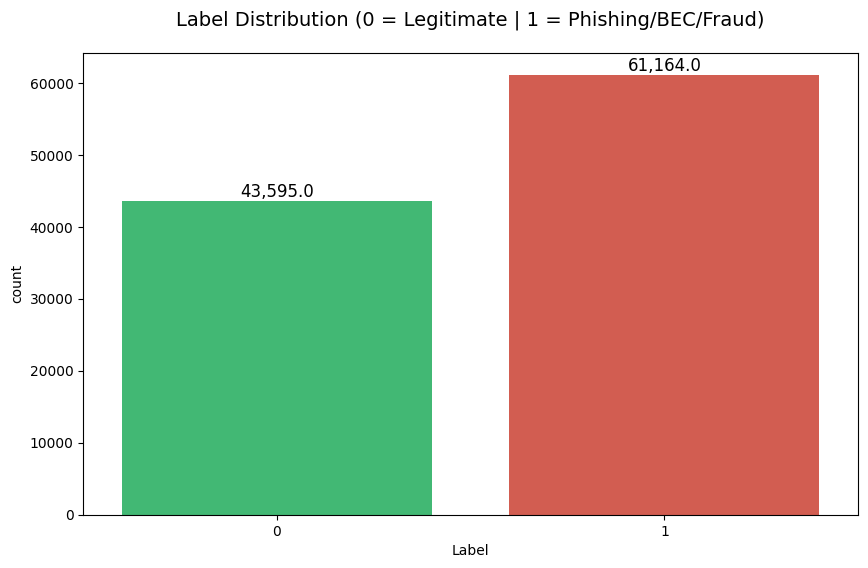


Source-wise Fraud Rate:
label                          0           1
source                                      
bec_adversarial         0.000000  100.000000
nigerian_fraud          0.000000  100.000000
phishing_dataset       48.004995   51.995005
synthetic_phish_legit  40.000000   60.000000


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import numpy as np
from collections import Counter
import re

# Load unified data
df = pd.read_csv('data/processed/unified_emails.csv')
print(f"Total emails: {len(df):,}")
print(df['label'].value_counts())

# Label distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='label', palette=['#2ecc71', '#e74c3c'])
plt.title('Label Distribution (0 = Legitimate | 1 = Phishing/BEC/Fraud)', fontsize=14, pad=20)
plt.xlabel('Label')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width()/2., p.get_height()), 
                ha='center', va='bottom', fontsize=12)
plt.show()

print("\nSource-wise Fraud Rate:")
print(pd.crosstab(df['source'], df['label'], normalize='index') * 100)

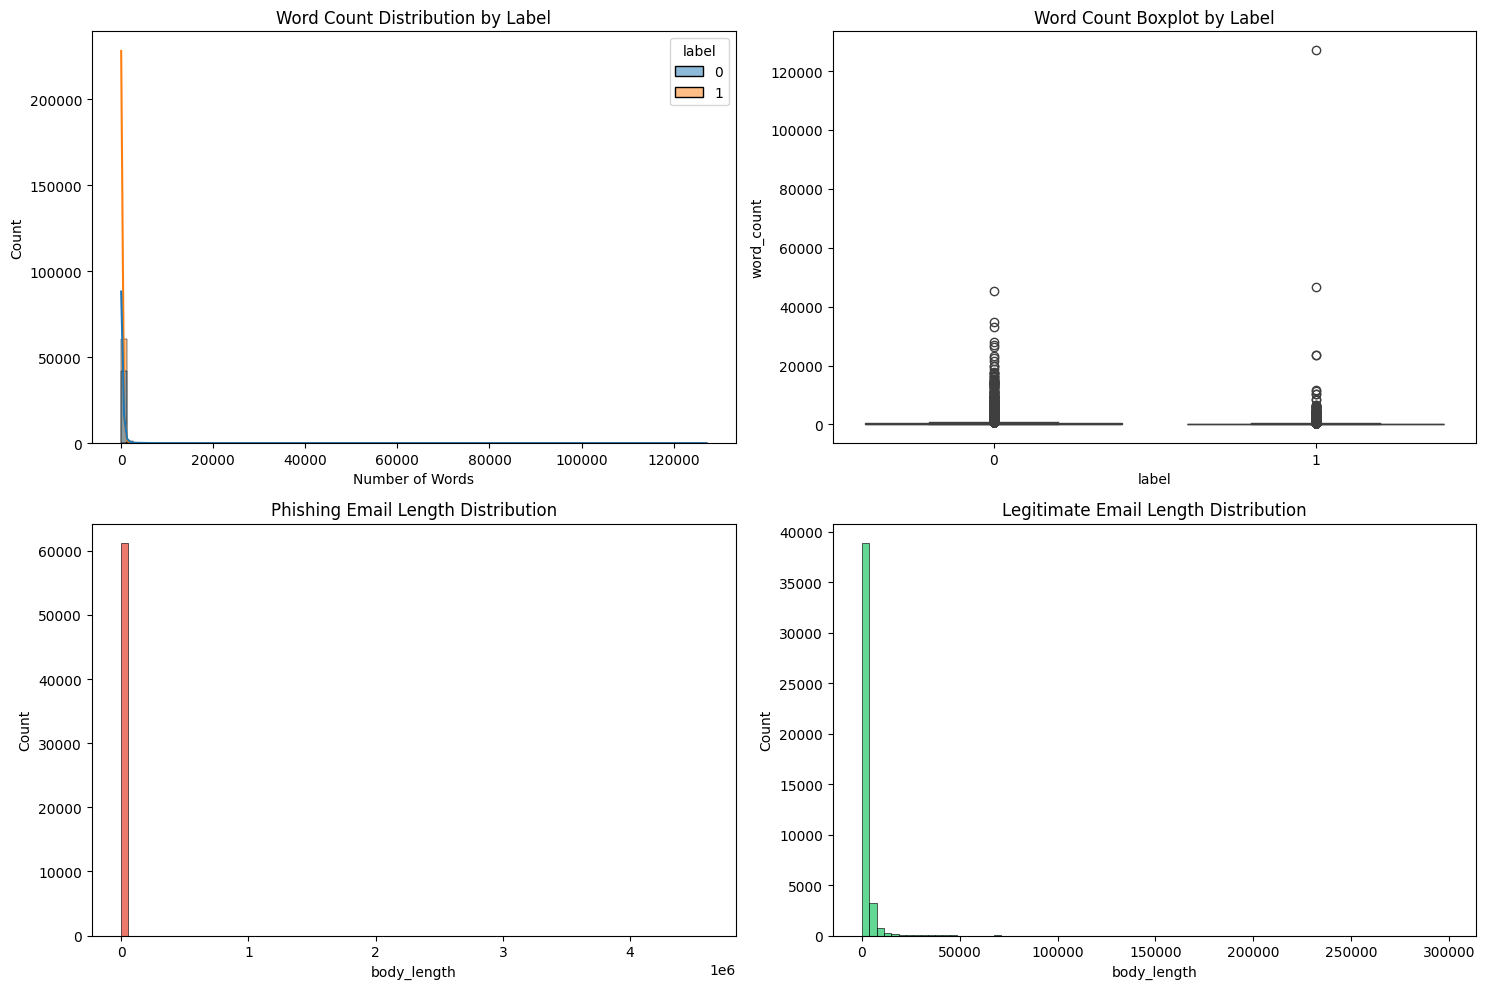

Summary Statistics:
      word_count                                                             \
           count        mean         std  min   25%    50%    75%       max   
label                                                                         
0        43595.0  326.956761  827.084092  1.0  66.0  161.0  342.0   45448.0   
1        61164.0  181.914214  644.971575  1.0  36.0   66.0  219.0  127119.0   

      body_length                                                         \
            count         mean           std  min    25%    50%      75%   
label                                                                      
0         43595.0  1979.573047   5164.165195  1.0  383.0  947.0  1966.50   
1         61164.0  1298.093110  19556.535020  1.0  232.0  401.0  1259.25   

                  
             max  
label             
0       299201.0  
1      4599644.0  


In [20]:
# Text length analysis
df['body_length'] = df['body'].str.len()
df['word_count'] = df['body'].str.split().str.len()
df['subject_length'] = df['subject'].fillna('').str.len()

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
sns.histplot(data=df, x='word_count', hue='label', bins=100, kde=True)
plt.title('Word Count Distribution by Label')
plt.xlabel('Number of Words')

plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='label', y='word_count')
plt.title('Word Count Boxplot by Label')

plt.subplot(2, 2, 3)
sns.histplot(data=df[df['label']==1], x='body_length', color='#e74c3c', bins=80)
plt.title('Phishing Email Length Distribution')

plt.subplot(2, 2, 4)
sns.histplot(data=df[df['label']==0], x='body_length', color='#2ecc71', bins=80)
plt.title('Legitimate Email Length Distribution')

plt.tight_layout()
plt.show()

print("Summary Statistics:")
print(df.groupby('label')[['word_count', 'body_length']].describe())

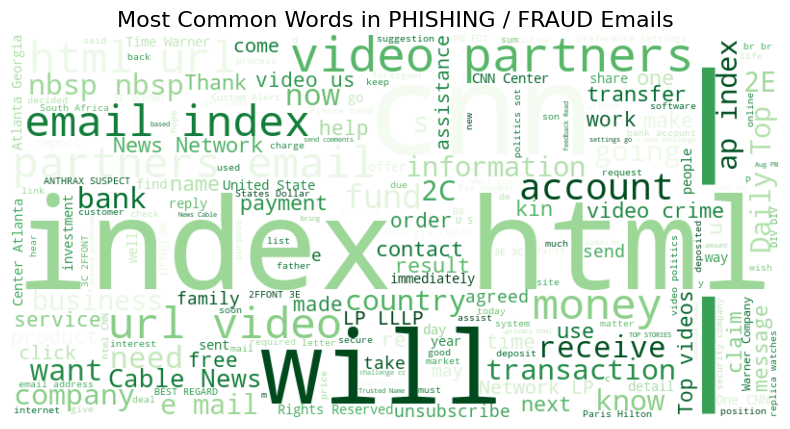

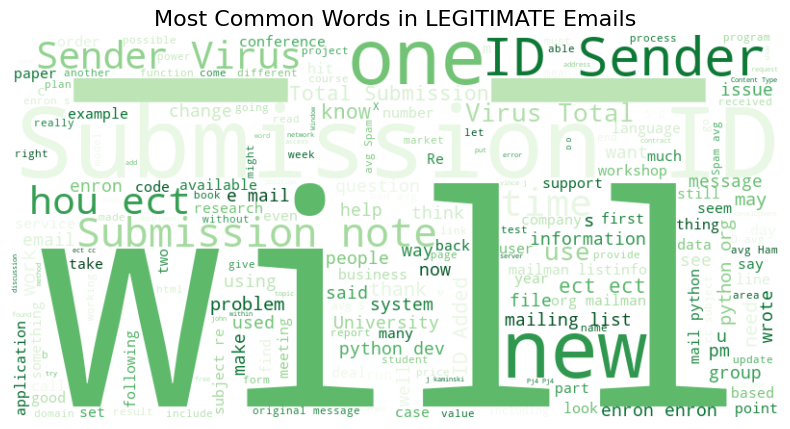

In [21]:
# Word Clouds
def create_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, 
                         background_color='white', 
                         max_words=200, 
                         colormap='Reds' if 'Fraud' in title else 'Greens').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

# Combine text
phish_text = " ".join(df[df['label']==1]['full_text'].astype(str).sample(5000, random_state=42))
legit_text = " ".join(df[df['label']==0]['full_text'].astype(str).sample(5000, random_state=42))

create_wordcloud(phish_text, "Most Common Words in PHISHING / FRAUD Emails")
create_wordcloud(legit_text, "Most Common Words in LEGITIMATE Emails")

In [22]:
# Nigerian / African scam indicators
urgency_words = ['urgent', 'immediately', 'now', 'today', 'asap', 'confidential', 'secret', 'deal', 'transfer', 'inheritance', 
                 'lottery', 'winner', 'fund', 'million', 'usd', 'naira', 'western union', 'money gram']

nigerian_indicators = ['nigeria', 'lagos', 'abuja', 'ekiti', 'oyo', 'benin', 'ghana', 'ivory coast', 'bank of nigeria']

df['has_urgency'] = df['full_text'].str.lower().str.contains('|'.join(urgency_words))
df['has_nigerian'] = df['full_text'].str.lower().str.contains('|'.join(nigerian_indicators))

print("🚨 SCAM PATTERN ANALYSIS")
print(f"Urgency words in Fraud emails: {df[df['label']==1]['has_urgency'].mean():.1%}")
print(f"Urgency words in Legit emails:  {df[df['label']==0]['has_urgency'].mean():.1%}")
print(f"Nigerian mention in Fraud:     {df[df['label']==1]['has_nigerian'].mean():.1%}")

# Cross tab
print("\nFraud Rate when Urgency words present:")
print(pd.crosstab(df['has_urgency'], df['label'], normalize='index') * 100)

🚨 SCAM PATTERN ANALYSIS
Urgency words in Fraud emails: 54.2%
Urgency words in Legit emails:  52.4%
Nigerian mention in Fraud:     4.6%

Fraud Rate when Urgency words present:
label                0          1
has_urgency                      
False        42.538048  57.461952
True         40.810642  59.189358


In [23]:
def get_top_words(text_series, n=30):
    all_text = ' '.join(text_series.astype(str)).lower()
    # Simple cleaning
    all_text = re.sub(r'[^a-z\s]', '', all_text)
    words = all_text.split()
    return Counter(words).most_common(n)

print("🔝 TOP 20 WORDS IN FRAUD EMAILS:")
print(get_top_words(df[df['label']==1]['full_text'], 20))

print("\n🔝 TOP 20 WORDS IN LEGIT EMAILS:")
print(get_top_words(df[df['label']==0]['full_text'], 20))

🔝 TOP 20 WORDS IN FRAUD EMAILS:
[('the', 354205), ('to', 304964), ('of', 227580), ('and', 210680), ('you', 160628), ('a', 156391), ('in', 145967), ('your', 142385), ('this', 127611), ('for', 117546), ('i', 107881), ('is', 101307), ('that', 69531), ('as', 69450), ('my', 67409), ('with', 64819), ('will', 63800), ('from', 61093), ('be', 59076), ('on', 56010)]

🔝 TOP 20 WORDS IN LEGIT EMAILS:
[('the', 476239), ('to', 307229), ('and', 228326), ('of', 227081), ('a', 192623), ('in', 179286), ('for', 132617), ('is', 120688), ('i', 108314), ('on', 102102), ('that', 97375), ('this', 83539), ('you', 82832), ('it', 77915), ('be', 74275), ('as', 73304), ('with', 69974), ('from', 62247), ('at', 58841), ('are', 56451)]


In [24]:
# Save key insights
eda_report = {
    'total_emails': len(df),
    'fraud_ratio': (df['label'].mean() * 100),
    'avg_words_fraud': df[df['label']==1]['word_count'].mean(),
    'avg_words_legit': df[df['label']==0]['word_count'].mean(),
    'urgency_in_fraud': df[df['label']==1]['has_urgency'].mean() * 100,
}

pd.Series(eda_report).to_csv('reports/eda_summary.csv')
print("\n✅ EDA Summary saved to reports/eda_summary.csv")


✅ EDA Summary saved to reports/eda_summary.csv


In [25]:
import re
import string
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|@\S+', '', text)  # Remove URLs and mentions
    text = re.sub(r'\d+', '', text)                   # Remove numbers (optional for fraud)
    text = re.sub(r'[^a-z\s]', ' ', text)             # Keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stopwords
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply cleaning
df['clean_body'] = df['body'].apply(clean_text)
df['clean_subject'] = df['subject'].fillna('').apply(clean_text)
df['clean_full_text'] = df['clean_subject'] + " " + df['clean_body']

print("✅ Text cleaning completed")

✅ Text cleaning completed


In [26]:
# =============================================================================
# HAND-CRAFTED FEATURES (High interpretability)
# =============================================================================

# 1. Urgency & Emotional Manipulation
urgency_terms = ['urgent', 'immediately', 'asap', 'now', 'today', 'confidential', 
                 'secret', 'act fast', 'limited time', 'last chance', 'warning']
df['urgency_score'] = df['full_text'].str.lower().str.count('|'.join(urgency_terms))

# 2. Money & Transfer Keywords (Very common in Nigerian scams)
money_terms = ['usd', 'naira', 'transfer', 'western union', 'moneygram', 'inheritance', 
               'lottery', 'million', 'funds', 'payment', 'bank account', 'wire']
df['money_score'] = df['full_text'].str.lower().str.count('|'.join(money_terms))

# 3. Nigerian / African Context
nigeria_terms = ['nigeria', 'lagos', 'abuja', 'ekiti', 'oyo', 'benin', 'ghana', 'cameroon']
df['nigeria_score'] = df['full_text'].str.lower().str.count('|'.join(nigeria_terms))

# 4. Spelling / Grammar Error Rate (Proxy)
def count_spelling_errors(text):
    words = text.split()
    # Simple heuristic: words with unusual characters or very short/long
    errors = sum(1 for w in words if (len(w) > 20 or len(w) == 1 and w not in ['a','i']))
    return errors

df['spelling_error_rate'] = df['body'].apply(count_spelling_errors) / (df['word_count'] + 1)

# 5. Email Structure Features
df['has_html_tags'] = df['body'].str.contains('<|&lt;', na=False).astype(int)
df['has_attach_mention'] = df['body'].str.contains('attach|attachment|file|document|pdf', case=False, na=False).astype(int)
df['subject_length'] = df['subject'].str.len()
df['body_length_ratio'] = df['body_length'] / (df['subject_length'] + 1)

print("✅ Custom security features created")
print(df[['urgency_score', 'money_score', 'nigeria_score', 'spelling_error_rate']].describe())

✅ Custom security features created
       urgency_score    money_score  nigeria_score  spelling_error_rate
count  104759.000000  104759.000000  104759.000000        104759.000000
mean        1.212583       0.752966       0.083773             0.125711
std         3.242071       3.238153       0.707969             0.137991
min         0.000000       0.000000       0.000000             0.000000
25%         0.000000       0.000000       0.000000             0.023622
50%         0.000000       0.000000       0.000000             0.076923
75%         1.000000       0.000000       0.000000             0.186441
max       414.000000     539.000000      88.000000             0.992094


In [27]:
# TF-IDF on full cleaned text
print("Creating TF-IDF features...")

tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 3),
    min_df=5,
    max_df=0.85,
    stop_words='english'
)

X_tfidf = tfidf.fit_transform(df['clean_full_text'])

print(f"TF-IDF shape: {X_tfidf.shape}")

# Save vectorizerx
import joblib
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')
print("✅ TF-IDF vectorizer saved")

Creating TF-IDF features...
TF-IDF shape: (104759, 8000)
✅ TF-IDF vectorizer saved


In [28]:
from transformers import BertTokenizer
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize with truncation & padding
def tokenize_for_bert(texts, max_length=256):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )

print("Tokenizing for BERT (this may take a moment)...")

# Sample for faster development (you can remove .sample() later)
sample_size = min(50000, len(df))  # Adjust based on your RAM
df_sample = df.sample(sample_size, random_state=42).reset_index(drop=True)

bert_inputs = tokenize_for_bert(df_sample['clean_full_text'])

print(f"BERT tokenization completed. Input shape: {bert_inputs['input_ids'].shape}")

# Save tokenized data
torch.save(bert_inputs, 'data/processed/bert_inputs.pt')
df_sample.to_csv('data/processed/df_for_bert.csv', index=False)

print("✅ BERT-ready tokenized data saved")

Tokenizing for BERT (this may take a moment)...
BERT tokenization completed. Input shape: torch.Size([50000, 256])


MemoryError: 

In [29]:
# Combine all engineered features
feature_cols = ['urgency_score', 'money_score', 'nigeria_score', 
                'spelling_error_rate', 'has_html_tags', 'has_attach_mention',
                'subject_length', 'body_length_ratio', 'word_count']

X_handcrafted = df[feature_cols].fillna(0)

print(f"Handcrafted features: {X_handcrafted.shape}")
print(f"TF-IDF features: {X_tfidf.shape}")

# Save everything
df.to_csv('data/processed/df_engineered.csv', index=False)
joblib.dump(X_handcrafted, 'data/processed/handcrafted_features.pkl')

print("\n🎉 FEATURE ENGINEERING COMPLETED!")
print(f"Total engineered samples: {len(df):,}")

Handcrafted features: (104759, 9)
TF-IDF features: (104759, 8000)

🎉 FEATURE ENGINEERING COMPLETED!
Total engineered samples: 104,759


In [30]:
from sklearn.model_selection import train_test_split
import joblib
import pandas as pd

# Load engineered data
df = pd.read_csv('data/processed/df_engineered.csv')

print("🔄 Creating Train / Validation / Test Split (Stratified)...")

# Features and target
feature_cols_to_drop = ['label', 'source', 'full_text', 'subject', 'body', 
                       'clean_body', 'clean_subject', 'clean_full_text']

X = df.drop(columns=feature_cols_to_drop, errors='ignore')
y = df['label']

# First split: Train (70%) vs Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

# Second split: Validation (15%) vs Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    random_state=42, 
    stratify=y_temp
)

# Also split the raw text for BERT
text_train, text_temp, y_text_train, y_text_temp = train_test_split(
    df['clean_full_text'], y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

text_val, text_test, y_text_val, y_text_test = train_test_split(
    text_temp, y_text_temp, 
    test_size=0.50, 
    random_state=42, 
    stratify=y_text_temp
)

print("✅ Final Split Summary:")
print(f"   Train set        : {len(X_train):,} samples ({len(X_train)/len(df)*100:.1f}%)")
print(f"   Validation set   : {len(X_val):,} samples ({len(X_val)/len(df)*100:.1f}%)")
print(f"   Test set         : {len(X_test):,} samples ({len(X_test)/len(df)*100:.1f}%)")
print("-" * 50)
print(f"   Fraud rate (Train) : {y_train.mean():.1%}")
print(f"   Fraud rate (Val)   : {y_val.mean():.1%}")
print(f"   Fraud rate (Test)  : {y_test.mean():.1%}")

# Save all splits
split_data = {
    'X_train': X_train,
    'X_val': X_val,
    'X_test': X_test,
    'y_train': y_train,
    'y_val': y_val,
    'y_test': y_test,
    
    'text_train': text_train,
    'text_val': text_val,
    'text_test': text_test,
    'y_text_train': y_text_train,
    'y_text_val': y_text_val,
    'y_text_test': y_text_test,
    
    'feature_columns': list(X.columns)
}

joblib.dump(split_data, 'data/processed/train_val_test_split.pkl')
print("\n✅ Full Train/Val/Test split saved to: data/processed/train_val_test_split.pkl")

🔄 Creating Train / Validation / Test Split (Stratified)...
✅ Final Split Summary:
   Train set        : 73,331 samples (70.0%)
   Validation set   : 15,714 samples (15.0%)
   Test set         : 15,714 samples (15.0%)
--------------------------------------------------
   Fraud rate (Train) : 58.4%
   Fraud rate (Val)   : 58.4%
   Fraud rate (Test)  : 58.4%

✅ Full Train/Val/Test split saved to: data/processed/train_val_test_split.pkl


In [31]:
import numpy as np
from sklearn.impute import SimpleImputer

print("🔧 Fixing NaN and Inf values...")

# Load the split again
split_data = joblib.load('data/processed/train_val_test_split.pkl')

X_train = split_data['X_train'].copy()
X_val   = split_data['X_val'].copy()
X_test  = split_data['X_test'].copy()

# Replace inf with NaN
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_val   = X_val.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)

# Impute missing values with median (robust to outliers)
imputer = SimpleImputer(strategy='median')

X_train = pd.DataFrame(imputer.fit_transform(X_train), 
                      columns=X_train.columns, index=X_train.index)
X_val   = pd.DataFrame(imputer.transform(X_val), 
                      columns=X_val.columns, index=X_val.index)
X_test  = pd.DataFrame(imputer.transform(X_test), 
                      columns=X_test.columns, index=X_test.index)

print("✅ NaN/Inf values handled successfully!")

# Update the split_data and save
split_data['X_train'] = X_train
split_data['X_val']   = X_val
split_data['X_test']  = X_test
joblib.dump(split_data, 'data/processed/train_val_test_split.pkl')

print(f"Final feature shape: {X_train.shape}")

🔧 Fixing NaN and Inf values...
✅ NaN/Inf values handled successfully!
Final feature shape: (73331, 12)


In [32]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the splits
split_data = joblib.load('data/processed/train_val_test_split.pkl')

X_train = split_data['X_train']
X_val   = split_data['X_val']
X_test  = split_data['X_test']
y_train = split_data['y_train']
y_val   = split_data['y_val']
y_test  = split_data['y_test']

print("✅ Data loaded successfully")
print(f"Class distribution in Train: {y_train.value_counts(normalize=True)}")

✅ Data loaded successfully
Class distribution in Train: label
1    0.583859
0    0.416141
Name: proportion, dtype: float64


🚀 Training Logistic Regression with Class Weights...
✅ Logistic Regression trained and saved

LOGISTIC REGRESSION - VALIDATION RESULTS
                    precision    recall  f1-score   support

    Legitimate (0)       0.68      0.66      0.67      6539
Phishing/Fraud (1)       0.76      0.78      0.77      9175

          accuracy                           0.73     15714
         macro avg       0.72      0.72      0.72     15714
      weighted avg       0.73      0.73      0.73     15714



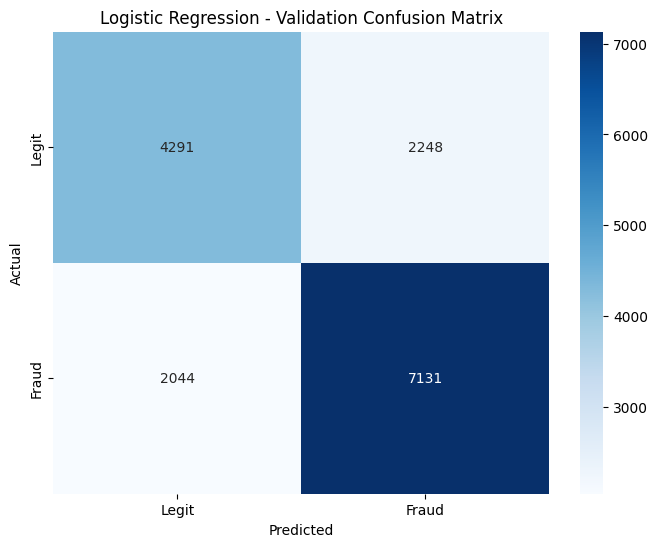


ROC-AUC Score (Validation): 0.8052


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print("🚀 Training Logistic Regression with Class Weights...")

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        random_state=42,
        max_iter=1000,
        C=1.0,
        solver='lbfgs'
    ))
])

lr_pipeline.fit(X_train, y_train)

# Save
joblib.dump(lr_pipeline, 'models/logistic_regression.pkl')
print("✅ Logistic Regression trained and saved")

# Validation Evaluation
y_val_pred = lr_pipeline.predict(X_val)
y_val_prob = lr_pipeline.predict_proba(X_val)[:, 1]

print("\n" + "="*65)
print("LOGISTIC REGRESSION - VALIDATION RESULTS")
print("="*65)
print(classification_report(y_val, y_val_pred, 
                          target_names=['Legitimate (0)', 'Phishing/Fraud (1)']))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_val, y_val_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Logistic Regression - Validation Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"\nROC-AUC Score (Validation): {roc_auc_score(y_val, y_val_prob):.4f}")

🌲 Training Random Forest with Class Weights...
✅ Random Forest trained and saved

RANDOM FOREST - VALIDATION RESULTS
                    precision    recall  f1-score   support

    Legitimate (0)       0.84      0.87      0.86      6539
Phishing/Fraud (1)       0.91      0.88      0.89      9175

          accuracy                           0.88     15714
         macro avg       0.87      0.88      0.87     15714
      weighted avg       0.88      0.88      0.88     15714



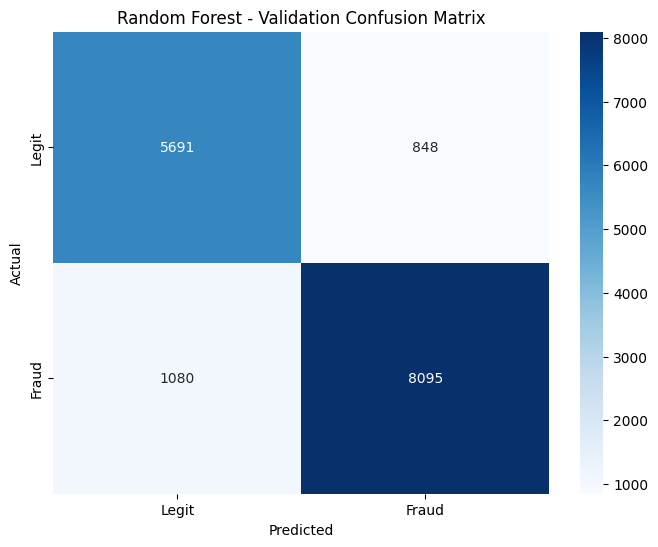


ROC-AUC Score (Validation): 0.9514

🔝 Top 10 Most Important Features:
spelling_error_rate    0.221208
body_length            0.194970
body_length_ratio      0.157136
word_count             0.156236
subject_length         0.105609
money_score            0.072908
has_attach_mention     0.032563
urgency_score          0.027210
has_html_tags          0.010497
has_urgency            0.009222
dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

print("🌲 Training Random Forest with Class Weights...")

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',      # Important for fraud
    random_state=42,
    n_jobs=-1,                    # Use all CPU cores
    bootstrap=True
)

# Train on Train set
rf_model.fit(X_train, y_train)

# Save model
joblib.dump(rf_model, 'models/random_forest.pkl')
print("✅ Random Forest trained and saved")

# Validation Evaluation
y_val_pred_rf = rf_model.predict(X_val)
y_val_prob_rf = rf_model.predict_proba(X_val)[:, 1]

print("\n" + "="*65)
print("RANDOM FOREST - VALIDATION RESULTS")
print("="*65)
print(classification_report(y_val, y_val_pred_rf, 
                          target_names=['Legitimate (0)', 'Phishing/Fraud (1)']))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_val, y_val_pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Random Forest - Validation Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"\nROC-AUC Score (Validation): {roc_auc_score(y_val, y_val_prob_rf):.4f}")

# Feature Importance (Very Useful!)
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
print("\n🔝 Top 10 Most Important Features:")
print(importances.sort_values(ascending=False).head(10))

⚡ Training XGBoost with Class Weights...
✅ XGBoost model trained and saved

XGBOOST - VALIDATION RESULTS
                    precision    recall  f1-score   support

    Legitimate (0)       0.82      0.90      0.85      6539
Phishing/Fraud (1)       0.92      0.86      0.89      9175

          accuracy                           0.87     15714
         macro avg       0.87      0.88      0.87     15714
      weighted avg       0.88      0.87      0.87     15714



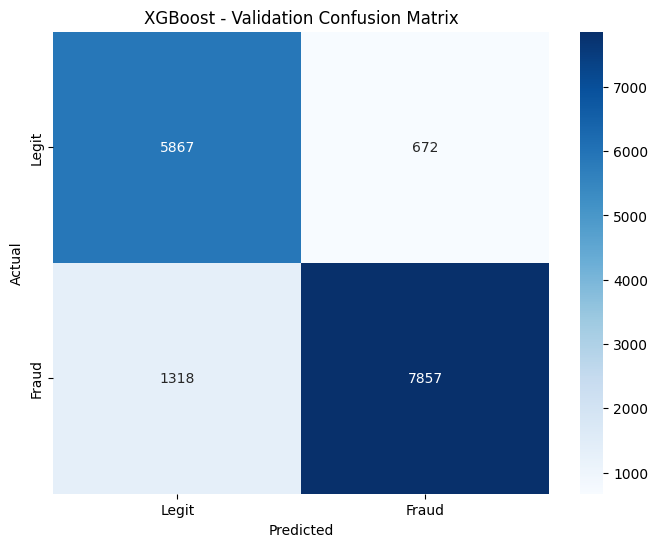


ROC-AUC Score (Validation): 0.9487

🔝 Top 10 Most Important Features (XGBoost):
has_nigerian           0.186021
money_score            0.138510
has_attach_mention     0.135272
has_html_tags          0.097237
nigeria_score          0.094870
body_length            0.072691
spelling_error_rate    0.068604
word_count             0.051180
body_length_ratio      0.046625
subject_length         0.041626
dtype: float32


In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print("⚡ Training XGBoost with Class Weights...")

# Calculate scale_pos_weight for better fraud handling
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,   # Very important for imbalance
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False
)

# Train
xgb_model.fit(X_train, y_train)

# Save model
joblib.dump(xgb_model, 'models/xgboost.pkl')
print("✅ XGBoost model trained and saved")

# Validation Evaluation
y_val_pred_xgb = xgb_model.predict(X_val)
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

print("\n" + "="*65)
print("XGBOOST - VALIDATION RESULTS")
print("="*65)
print(classification_report(y_val, y_val_pred_xgb, 
                          target_names=['Legitimate (0)', 'Phishing/Fraud (1)']))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_val, y_val_pred_xgb), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('XGBoost - Validation Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"\nROC-AUC Score (Validation): {roc_auc_score(y_val, y_val_prob_xgb):.4f}")

# Feature Importance
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)
print("\n🔝 Top 10 Most Important Features (XGBoost):")
print(importances.sort_values(ascending=False).head(10))

🌟 Training LightGBM with Class Weights...
✅ LightGBM model trained and saved

LIGHTGBM - VALIDATION RESULTS
                    precision    recall  f1-score   support

    Legitimate (0)       0.79      0.92      0.85      6539
Phishing/Fraud (1)       0.94      0.83      0.88      9175

          accuracy                           0.87     15714
         macro avg       0.86      0.88      0.87     15714
      weighted avg       0.88      0.87      0.87     15714



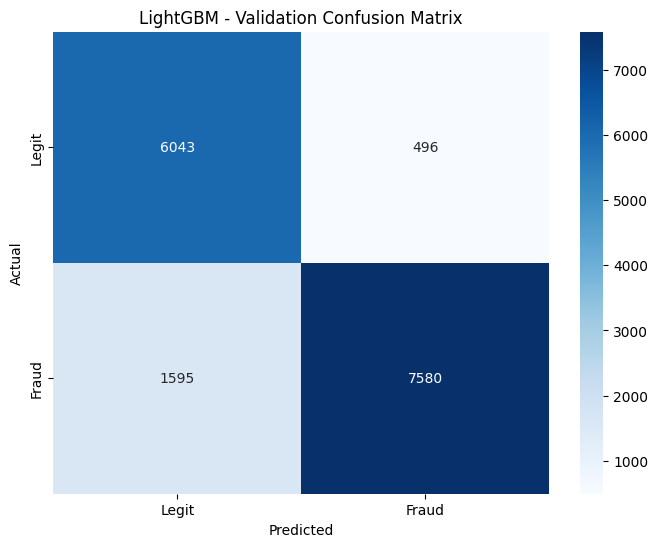


ROC-AUC Score (Validation): 0.9484

🔝 Top 10 Most Important Features (LightGBM):
spelling_error_rate    6505
body_length            5882
word_count             5734
subject_length         4583
body_length_ratio      4494
urgency_score          1512
money_score            1186
has_attach_mention      561
has_urgency             506
has_html_tags           188
dtype: int32


In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

print("🌟 Training LightGBM with Class Weights...")

# Calculate scale_pos_weight
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.08,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Train
lgb_model.fit(X_train, y_train)

# Save model
joblib.dump(lgb_model, 'models/lightgbm.pkl')
print("✅ LightGBM model trained and saved")

# Validation Evaluation
y_val_pred_lgb = lgb_model.predict(X_val)
y_val_prob_lgb = lgb_model.predict_proba(X_val)[:, 1]

print("\n" + "="*65)
print("LIGHTGBM - VALIDATION RESULTS")
print("="*65)
print(classification_report(y_val, y_val_pred_lgb, 
                          target_names=['Legitimate (0)', 'Phishing/Fraud (1)']))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_val, y_val_pred_lgb), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('LightGBM - Validation Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"\nROC-AUC Score (Validation): {roc_auc_score(y_val, y_val_prob_lgb):.4f}")

# Feature Importance
importances = pd.Series(lgb_model.feature_importances_, index=X_train.columns)
print("\n🔝 Top 10 Most Important Features (LightGBM):")
print(importances.sort_values(ascending=False).head(10))

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load all models and test data
models = {
    'Logistic Regression': joblib.load('models/logistic_regression.pkl'),
    'Random Forest': joblib.load('models/random_forest.pkl'),
    'XGBoost': joblib.load('models/xgboost.pkl'),
    'LightGBM': joblib.load('models/lightgbm.pkl')
}

split_data = joblib.load('data/processed/train_val_test_split.pkl')
X_test = split_data['X_test']
y_test = split_data['y_test']

print("🏆 FINAL TEST SET EVALUATION - ALL CLASSICAL MODELS\n")

results = []

for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    else:
        y_pred = model.predict(X_test)
        roc = None
    
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results.append({
        'Model': name,
        'Accuracy': round(report['accuracy'], 4),
        'Fraud Precision': round(report['1']['precision'], 4),
        'Fraud Recall': round(report['1']['recall'], 4),
        'Fraud F1': round(report['1']['f1-score'], 4),
        'ROC-AUC': round(roc, 4) if roc is not None else 'N/A'
    })
    
    print(f"\n{name.upper()}")
    print("-" * 50)
    print(classification_report(y_test, y_pred, 
                              target_names=['Legitimate (0)', 'Phishing/Fraud (1)']))

# Summary Table
summary_df = pd.DataFrame(results)
summary_df = summary_df.sort_values(by='Fraud Recall', ascending=False)

print("\n" + "="*80)
print("📊 FINAL COMPARISON TABLE (Test Set)")
print("="*80)
print(summary_df.round(4))

# Save comparison
summary_df.to_csv('reports/classical_models_comparison.csv', index=False)
print("\n✅ Comparison table saved to reports/classical_models_comparison.csv")

🏆 FINAL TEST SET EVALUATION - ALL CLASSICAL MODELS


LOGISTIC REGRESSION
--------------------------------------------------
                    precision    recall  f1-score   support

    Legitimate (0)       0.68      0.66      0.67      6540
Phishing/Fraud (1)       0.76      0.78      0.77      9174

          accuracy                           0.73     15714
         macro avg       0.72      0.72      0.72     15714
      weighted avg       0.73      0.73      0.73     15714


RANDOM FOREST
--------------------------------------------------
                    precision    recall  f1-score   support

    Legitimate (0)       0.85      0.88      0.86      6540
Phishing/Fraud (1)       0.91      0.89      0.90      9174

          accuracy                           0.88     15714
         macro avg       0.88      0.88      0.88     15714
      weighted avg       0.88      0.88      0.88     15714


XGBOOST
--------------------------------------------------
                    prec

In [ ]:
# Cleanup previous BERT attempts
import shutil
import os
from pathlib import Path

# Remove any conflicting BERT folders
folders_to_remove = ['bert-base-uncased', 'bert-base-uncased_backup*']
for folder in folders_to_remove:
    try:
        if Path(folder).exists():
            shutil.rmtree(folder, ignore_errors=True)
            print(f"✅ Removed {folder}")
    except:
        pass

print("✅ Cleanup completed. Ready for DistilBERT.")

✅ Cleanup completed. Ready for DistilBERT.


In [33]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.metrics import classification_report
import pandas as pd
import joblib
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Load data
split_data = joblib.load('data/processed/train_val_test_split.pkl')
text_train = split_data['text_train']
text_val   = split_data['text_val']
text_test  = split_data['text_test']

y_train = split_data['y_text_train'].values
y_val   = split_data['y_text_val'].values
y_test  = split_data['y_text_test'].values

print(f"✅ Training samples: {len(text_train):,}")

✅ Training samples: 73,331


In [34]:
class EmailDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts.reset_index(drop=True) if hasattr(texts, 'reset_index') else pd.Series(texts)
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts.iloc[idx]),
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

batch_size = 64   # Good for RTX 4050

train_dataset = EmailDataset(text_train, y_train, tokenizer)
val_dataset   = EmailDataset(text_val, y_val, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, pin_memory=True)

print("✅ DataLoaders ready")

✅ DataLoaders ready


In [ ]:
device = torch.device('cuda')
print(f"🚀 Training on: {torch.cuda.get_device_name(0)}")

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
).to(device)

optimizer = AdamW(model.parameters(), lr=3e-5)

total_steps = len(train_loader) * 4
scheduler = get_linear_schedule_with_warmup(optimizer, 
                                            num_warmup_steps=0, 
                                            num_training_steps=total_steps)

print("✅ Model loaded on GPU!")

🚀 Training on: NVIDIA GeForce RTX 4050 Laptop GPU


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6350.10it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded on GPU!


In [ ]:
epochs = 4
best_val_loss = float('inf')
best_model_path = 'models/best_distilbert.pth'

print("🎯 Starting DistilBERT Training on GPU...\n")

for epoch in range(epochs):
    # Training
    model.train()
    train_loss = 0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
    
    for batch in progress_bar:
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        
        loss.backward()
        optimizer.step()
        scheduler.step()
        
        train_loss += loss.item()
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_train_loss = train_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_loss = 0
    val_preds, val_true = [], []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            val_loss += outputs.loss.item()
            
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_true.extend(labels.cpu().numpy())
    
    avg_val_loss = val_loss / len(val_loader)
    
    print(f"\nEpoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"   → Best model saved!")
    
    print(classification_report(val_true, val_preds, target_names=['Legitimate', 'Phishing/Fraud'], digits=4))
    print("-" * 90)

🎯 Starting DistilBERT Training on GPU...



Epoch 1/4 [Train]: 100%|██████████| 1146/1146 [24:49<00:00,  1.30s/it, loss=0.0008]



Epoch 1/4 | Train Loss: 0.0103 | Val Loss: 0.0186
   → Best model saved!
                precision    recall  f1-score   support

    Legitimate     0.9936    0.9933    0.9934      6539
Phishing/Fraud     0.9952    0.9954    0.9953      9175

      accuracy                         0.9945     15714
     macro avg     0.9944    0.9943    0.9944     15714
  weighted avg     0.9945    0.9945    0.9945     15714

------------------------------------------------------------------------------------------


Epoch 2/4 [Train]: 100%|██████████| 1146/1146 [27:23<00:00,  1.43s/it, loss=0.0001]



Epoch 2/4 | Train Loss: 0.0032 | Val Loss: 0.0219
                precision    recall  f1-score   support

    Legitimate     0.9882    0.9962    0.9922      6539
Phishing/Fraud     0.9973    0.9915    0.9944      9175

      accuracy                         0.9934     15714
     macro avg     0.9927    0.9938    0.9933     15714
  weighted avg     0.9935    0.9934    0.9934     15714

------------------------------------------------------------------------------------------


Epoch 3/4 [Train]: 100%|██████████| 1146/1146 [23:49<00:00,  1.25s/it, loss=0.0001]



Epoch 3/4 | Train Loss: 0.0011 | Val Loss: 0.0207
                precision    recall  f1-score   support

    Legitimate     0.9933    0.9946    0.9940      6539
Phishing/Fraud     0.9962    0.9952    0.9957      9175

      accuracy                         0.9950     15714
     macro avg     0.9947    0.9949    0.9948     15714
  weighted avg     0.9950    0.9950    0.9950     15714

------------------------------------------------------------------------------------------


Epoch 4/4 [Train]: 100%|██████████| 1146/1146 [23:49<00:00,  1.25s/it, loss=0.0001]
                                                                  


Epoch 4/4 | Train Loss: 0.0007 | Val Loss: 0.0207
                precision    recall  f1-score   support

    Legitimate     0.9933    0.9946    0.9940      6539
Phishing/Fraud     0.9962    0.9952    0.9957      9175

      accuracy                         0.9950     15714
     macro avg     0.9947    0.9949    0.9948     15714
  weighted avg     0.9950    0.9950    0.9950     15714

------------------------------------------------------------------------------------------


In [35]:
# === Create Test Loader (if not already done) ===
test_dataset = EmailDataset(text_test, y_test, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=64, pin_memory=True)

print(f"✅ Test loader created with {len(test_dataset)} samples")

✅ Test loader created with 15714 samples


In [ ]:
# Load best model
model.load_state_dict(torch.load('models/best_distilbert.pth', weights_only=True))
model.eval()

print("🏆 FINAL EVALUATION - DISTILBERT on UNSEEN TEST SET\n")

test_preds = []
test_probs = []
test_true = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
        
        test_preds.extend(preds)
        test_probs.extend(probs)
        test_true.extend(labels.cpu().numpy())

print(classification_report(test_true, test_preds, 
                          target_names=['Legitimate (0)', 'Phishing/Fraud (1)'], 
                          digits=4))

from sklearn.metrics import roc_auc_score
print(f"\nTest ROC-AUC: {roc_auc_score(test_true, test_probs):.5f}")

# Save final model
final_model_path = 'models/distilbert_phishing_detector'
model.save_pretrained(final_model_path)
tokenizer.save_pretrained(final_model_path)
print(f"\n✅ Final DistilBERT model saved to: {final_model_path}")

🏆 FINAL EVALUATION - DISTILBERT on UNSEEN TEST SET



Testing: 100%|██████████| 246/246 [02:11<00:00,  1.87it/s]


                    precision    recall  f1-score   support

    Legitimate (0)     0.9936    0.9894    0.9915      6540
Phishing/Fraud (1)     0.9925    0.9954    0.9940      9174

          accuracy                         0.9929     15714
         macro avg     0.9930    0.9924    0.9927     15714
      weighted avg     0.9929    0.9929    0.9929     15714


Test ROC-AUC: 0.99971


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.57it/s]


✅ Final DistilBERT model saved to: models/distilbert_phishing_detector


In [36]:
import re

def extract_advanced_nlp_features(text):
    if not isinstance(text, str):
        text = str(text)
    text_lower = text.lower()
    
    features = {}
    
    # Nigerian-specific scam patterns
    features['nigeria_indicators'] = int(bool(re.search(r'nigeria|lagos|abuja|ekiti|oyo|benin|portharcourt', text_lower)))
    features['money_patterns'] = len(re.findall(r'\b(\d+[.,]?\d*)\s*(million|billion|thousand|usd|naira|dollars)\b', text_lower))
    features['authority_titles'] = len(re.findall(r'\b(dr|chief|prince|barr|prof|hon|senator|mr|mrs)\.?\s+[a-z]+', text_lower))
    features['greeting_scam'] = int(bool(re.search(r'dear friend|my dearest|beloved friend|urgent attention', text_lower)))
    features['threat_words'] = len(re.findall(r'account suspended|legal action|arrest|police|immediately|confidential', text_lower))
    
    # Improved spelling error proxy
    words = re.findall(r'\b\w+\b', text)
    long_words = sum(1 for w in words if len(w) > 20 or (len(w) > 12 and not w.isalpha()))
    features['unusual_word_ratio'] = long_words / (len(words) + 1)
    
    return features

# Apply to full dataset
print("Extracting advanced NLP features...")

df = pd.read_csv('data/processed/df_engineered.csv')

advanced_features = df['full_text'].apply(extract_advanced_nlp_features).apply(pd.Series)
df = pd.concat([df, advanced_features], axis=1)

print("✅ Advanced Nigerian-focused NLP features added")
print(advanced_features.mean().round(4))

Extracting advanced NLP features...
✅ Advanced Nigerian-focused NLP features added
nigeria_indicators    0.0223
money_patterns        0.1480
authority_titles      0.1746
greeting_scam         0.0176
threat_words          0.2464
unusual_word_ratio    0.0053
dtype: float64


In [37]:
# Add new features to handcrafted set
new_feature_cols = ['nigeria_indicators', 'money_patterns', 'authority_titles', 
                   'greeting_scam', 'threat_words', 'unusual_word_ratio']

# Reload splits and add new features if needed
# (For simplicity, we'll focus on SHAP for now on existing + new features)

Calculating SHAP values for Random Forest...


<Figure size 1200x800 with 0 Axes>

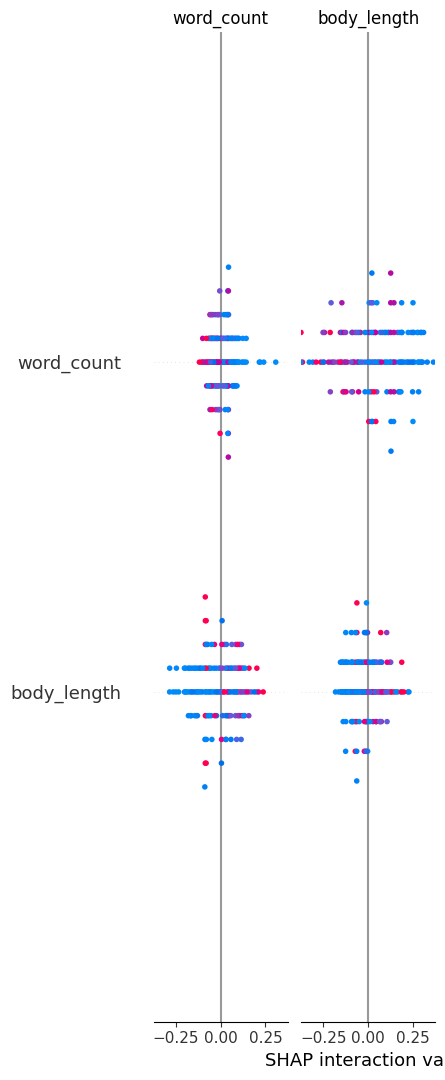

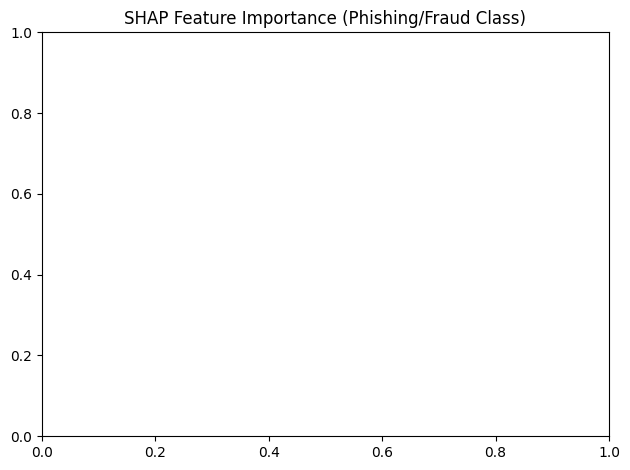

<Figure size 1200x800 with 0 Axes>

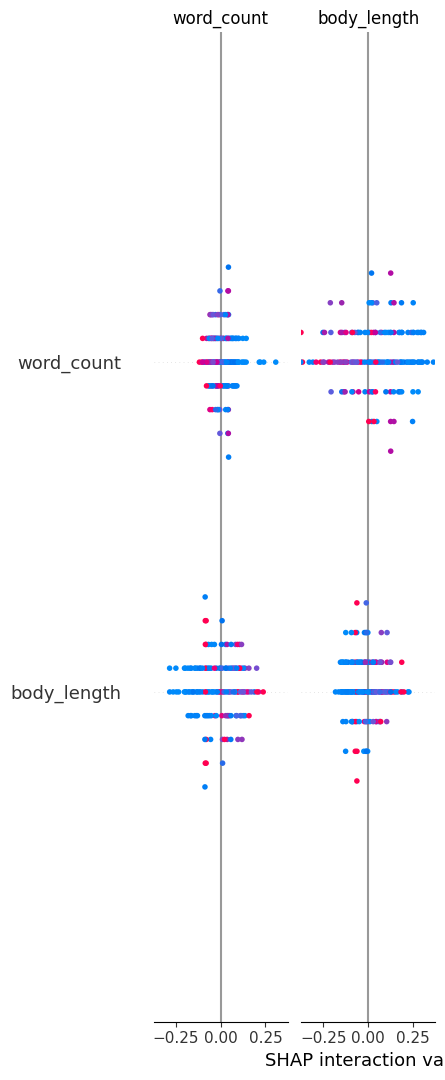

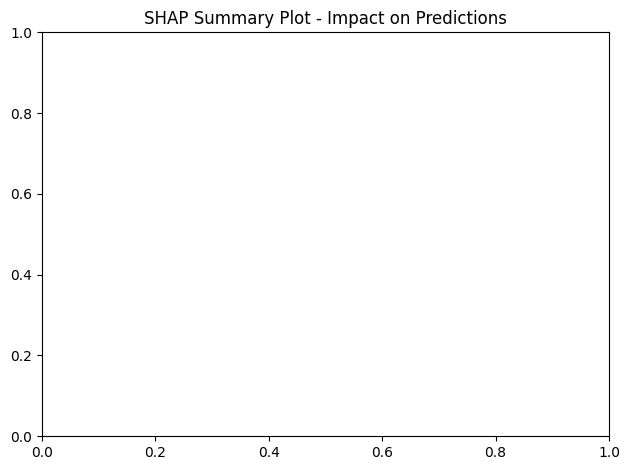

In [39]:
import shap
import matplotlib.pyplot as plt
import joblib

print("Calculating SHAP values for Random Forest...")

# Load model
rf_model = joblib.load('models/random_forest.pkl')

# Use smaller sample for speed + stability
X_sample = X_test.sample(150, random_state=42)

# Create explainer
explainer = shap.TreeExplainer(rf_model)

# Get SHAP values
shap_values = explainer.shap_values(X_sample)

# For binary classification, shap_values is usually a list: [class0, class1]
if isinstance(shap_values, list):
    shap_values_phish = shap_values[1]   # Phishing class (positive class)
    print(f"SHAP values shape for phishing class: {shap_values_phish.shape}")
else:
    shap_values_phish = shap_values

# Summary Plot - Feature Importance
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_phish, X_sample, plot_type="bar", max_display=15)
plt.title("SHAP Feature Importance (Phishing/Fraud Class)")
plt.tight_layout()
plt.show()

# Beeswarm Plot (shows direction + impact)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_phish, X_sample, max_display=15)
plt.title("SHAP Summary Plot - Impact on Predictions")
plt.tight_layout()
plt.show()

🔍 Generating SHAP Explainability Reports...



<Figure size 1400x800 with 0 Axes>

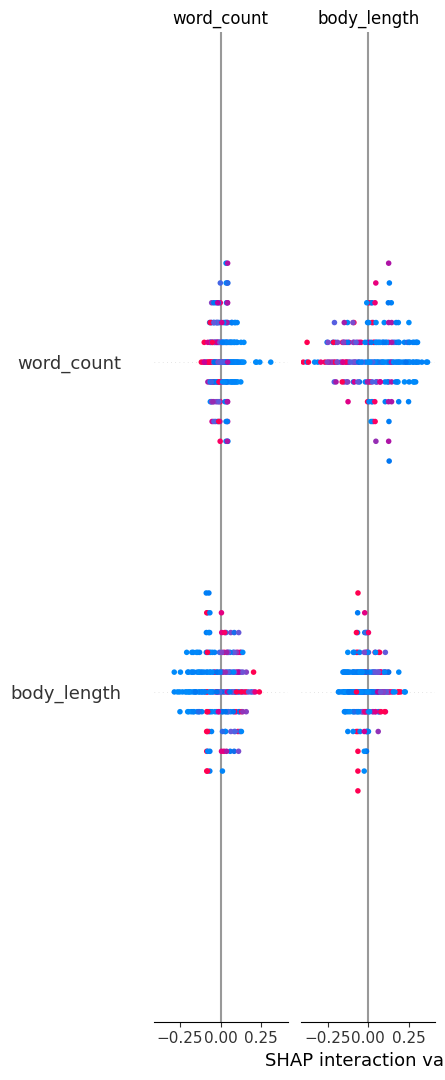

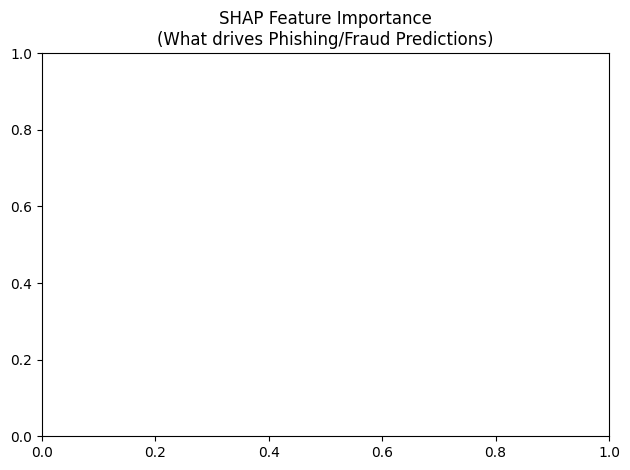

<Figure size 1400x1000 with 0 Axes>

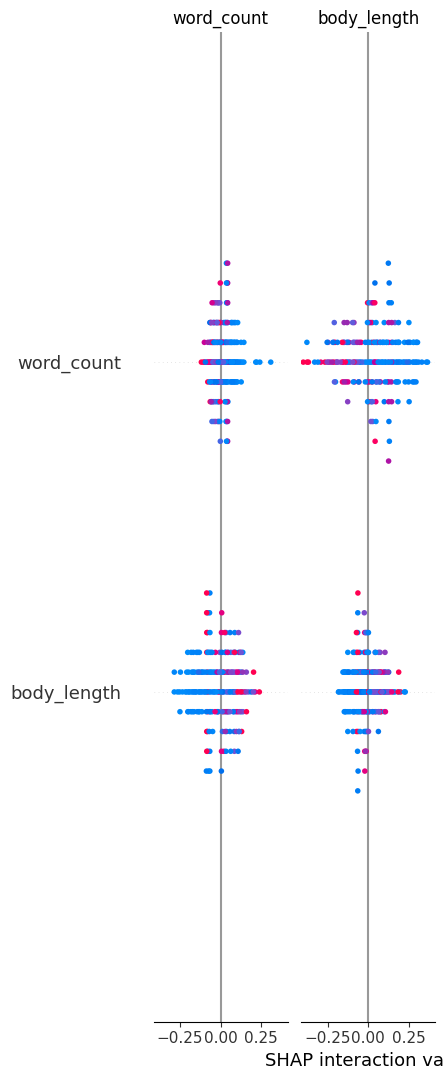

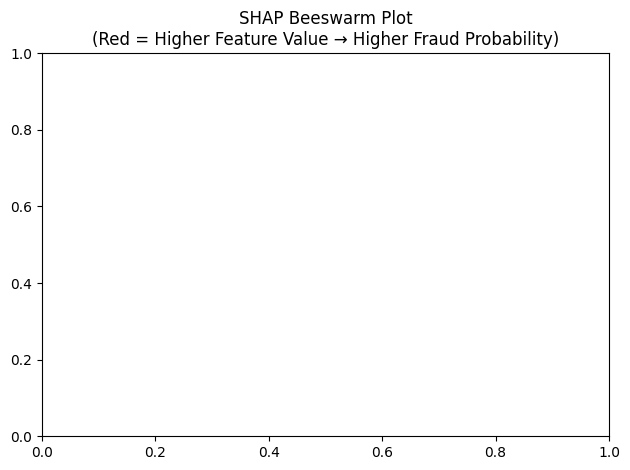

✅ SHAP Global Explainability completed!


In [49]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print("🔍 Generating SHAP Explainability Reports...\n")

# Load model
rf_model = joblib.load('models/random_forest.pkl')
X_sample = X_test.sample(200, random_state=42)   # Small sample for speed

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

# Handle binary output
if isinstance(shap_values, list):
    shap_values_phish = shap_values[1]   # Phishing class
else:
    shap_values_phish = shap_values

# ==================== MAIN PLOTS ====================

# 1. Top Features Importance
plt.figure(figsize=(14, 8))
shap.summary_plot(shap_values_phish, X_sample, plot_type="bar", max_display=20)
plt.title("SHAP Feature Importance\n(What drives Phishing/Fraud Predictions)")
plt.tight_layout()
plt.show()

# 2. Detailed Impact Plot
plt.figure(figsize=(14, 10))
shap.summary_plot(shap_values_phish, X_sample, max_display=20)
plt.title("SHAP Beeswarm Plot\n(Red = Higher Feature Value → Higher Fraud Probability)")
plt.tight_layout()
plt.show()

print("✅ SHAP Global Explainability completed!")

🔍 SHAP Explainability Analysis

SHAP values shape: (300, 12, 2)
🏆 TOP 15 MOST IMPORTANT FEATURES

                feature  mean_shap_impact
8   spelling_error_rate           0.12075
0           body_length           0.07285
6           money_score           0.06913
11    body_length_ratio           0.06594
1            word_count           0.05325
10   has_attach_mention           0.05078
2        subject_length           0.03123
5         urgency_score           0.01472
3           has_urgency           0.00908
4          has_nigerian           0.00746
9         has_html_tags           0.00603
7         nigeria_score           0.00393


<Figure size 1400x800 with 0 Axes>

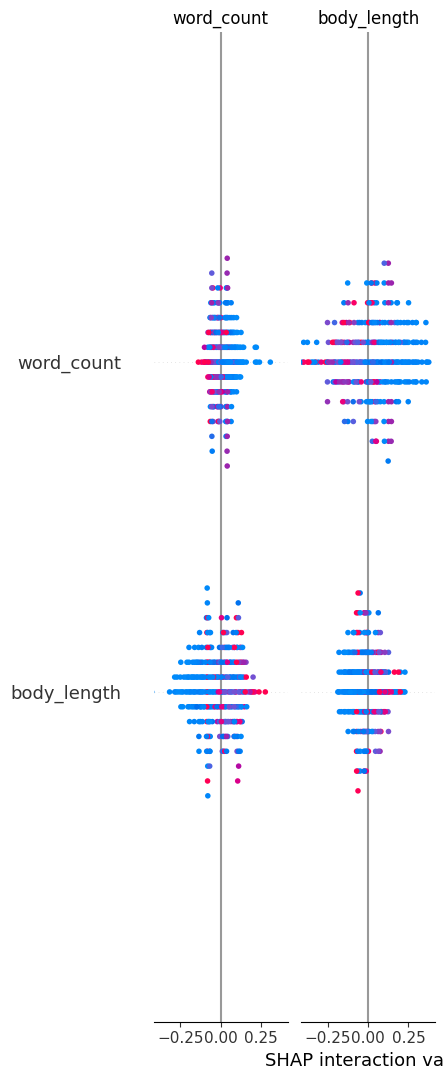

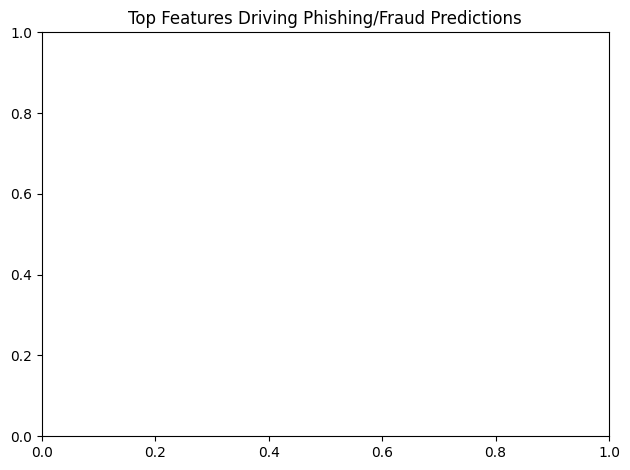

<Figure size 1400x1000 with 0 Axes>

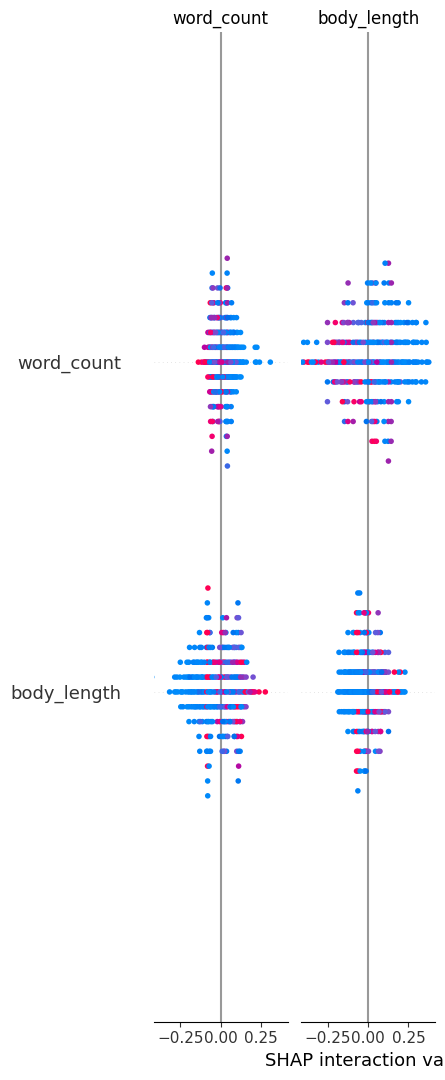

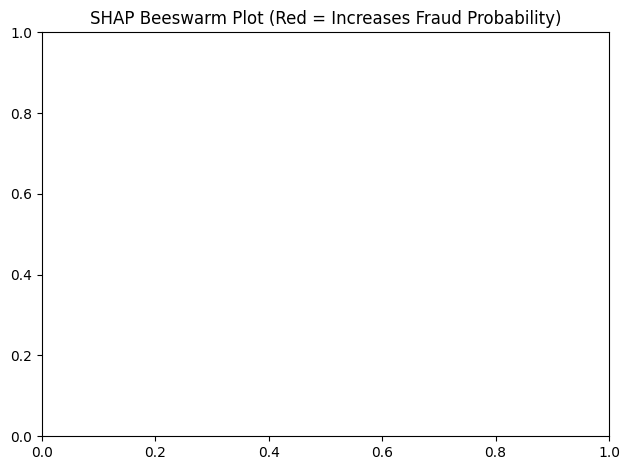

In [51]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("🔍 SHAP Explainability Analysis\n")

# Load model
rf_model = joblib.load('models/random_forest.pkl')

# Sample data
X_sample = X_test.sample(300, random_state=42)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

# Handle different output formats from TreeExplainer
if isinstance(shap_values, list):
    shap_values_phish = shap_values[1]        # Class 1 = Phishing/Fraud
else:
    shap_values_phish = shap_values

print(f"SHAP values shape: {np.array(shap_values_phish).shape}")

# ====================== TEXT RANKING ======================
# Flatten mean absolute impact safely
mean_abs_shap = np.abs(shap_values_phish).mean(axis=0)

# Ensure it's 1D
if len(mean_abs_shap.shape) > 1:
    mean_abs_shap = mean_abs_shap.mean(axis=1)   # fallback

shap_importance = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_shap_impact': mean_abs_shap
}).sort_values('mean_shap_impact', ascending=False)

print("🏆 TOP 15 MOST IMPORTANT FEATURES\n")
print(shap_importance.head(15).round(5))

# ====================== PLOTS ======================
plt.figure(figsize=(14, 8))
shap.summary_plot(shap_values_phish, X_sample, plot_type="bar", max_display=15)
plt.title("Top Features Driving Phishing/Fraud Predictions")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 10))
shap.summary_plot(shap_values_phish, X_sample, max_display=15)
plt.title("SHAP Beeswarm Plot (Red = Increases Fraud Probability)")
plt.tight_layout()
plt.show()

In [52]:
import re

def extract_advanced_nlp_features(text):
    if not isinstance(text, str):
        text = str(text)
    t = text.lower()
    
    features = {}
    
    # Strong Nigerian Scam Patterns
    features['western_union'] = int('western union' in t or 'money gram' in t or 'moneygram' in t)
    features['next_of_kin'] = int('next of kin' in t or 'inheritance' in t or 'will' in t)
    features['lottery_scam'] = int('lottery' in t or 'winner' in t or 'congratulation' in t)
    features['bank_transfer'] = len(re.findall(r'(bank.*transfer|transfer.*fund|wire.*money|account.*number)', t))
    features['urgent_action'] = len(re.findall(r'(immediately|asap|today|now|urgent|act fast)', t))
    features['authority_title'] = len(re.findall(r'\b(dr|chief|prince|barr|prof|senator|hon)\.?\s', t))
    features['greeting_scam'] = int(bool(re.search(r'dear friend|my dearest|beloved|attention please', t)))
    features['threat_words'] = len(re.findall(r'(arrest|police|legal action|suspend|block|hack)', t))
    
    # Linguistic Red Flags
    features['all_caps_ratio'] = sum(1 for c in text if c.isupper()) / (len(text) + 1)
    features['exclamation_ratio'] = text.count('!') / (len(text) + 1)
    features['question_ratio'] = text.count('?') / (len(text) + 1)
    
    return features

print("Extracting Advanced Nigerian NLP Features...")

df = pd.read_csv('data/processed/df_engineered.csv')

advanced_feats = df['full_text'].apply(extract_advanced_nlp_features).apply(pd.Series)
df = pd.concat([df, advanced_feats], axis=1)

print(f"✅ Added {len(advanced_feats.columns)} new advanced NLP features")
print(advanced_feats.mean().round(4))

Extracting Advanced Nigerian NLP Features...
✅ Added 11 new advanced NLP features
western_union        0.0006
next_of_kin          0.3480
lottery_scam         0.0162
bank_transfer        0.0496
urgent_action        1.0282
authority_title      0.0916
greeting_scam        0.0207
threat_words         0.1453
all_caps_ratio       0.0454
exclamation_ratio    0.0014
question_ratio       0.0011
dtype: float64


In [54]:
import torch
import joblib
import re

# Ensure device is defined
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load models
rf_model = joblib.load('models/random_forest.pkl')

distil_model = DistilBertForSequenceClassification.from_pretrained('models/distilbert_phishing_detector')
distil_model.to(device)
distil_model.eval()

tokenizer = DistilBertTokenizer.from_pretrained('models/distilbert_phishing_detector')

print("✅ Models loaded successfully")

# Dynamic Zero-Day Rule Engine
zero_day_rules = {
    "high_risk_phrases": ["bitcoin", "crypto", "refund", "irs", "double your money", "secret deal"],
    "new_scam_indicators": []
}

def extract_advanced_nlp_features(text):
    if not isinstance(text, str):
        text = str(text)
    t = text.lower()
    
    features = {}
    features['western_union'] = int('western union' in t or 'moneygram' in t)
    features['next_of_kin'] = int('next of kin' in t or 'inheritance' in t)
    features['lottery'] = int('lottery' in t or 'winner' in t)
    features['bank_transfer'] = len(re.findall(r'bank.*transfer|transfer.*fund|wire.*money', t))
    features['urgent_action'] = len(re.findall(r'immediately|asap|today|now|urgent|act fast', t))
    features['authority_title'] = len(re.findall(r'\b(dr|chief|prince|barr|prof|senator)\.?\s', t))
    features['all_caps_ratio'] = sum(1 for c in text if c.isupper()) / (len(text) + 1)
    features['exclamation_ratio'] = text.count('!') / (len(text) + 1)
    return features

def predict_email(email_text: str):
    """Main Production Function - Hybrid ML + Zero-Day Defense"""
    
    result = {
        "verdict": None,
        "probability": None,
        "confidence": None,
        "zero_day_warning": False,
        "explanation": []
    }
    
    # 1. DistilBERT Prediction
    inputs = tokenizer(email_text, return_tensors="pt", truncation=True, max_length=256, padding=True).to(device)
    with torch.no_grad():
        outputs = distil_model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        fraud_prob = probs[0][1].item()
    
    # 2. Advanced NLP Features
    features = extract_advanced_nlp_features(email_text)
    
    # 3. Zero-Day Defense Layer
    zero_day_score = 0.0
    reasons = []
    
    if any(phrase in email_text.lower() for phrase in zero_day_rules["high_risk_phrases"]):
        zero_day_score += 0.35
        reasons.append("New high-risk phrase detected")
    
    if features['all_caps_ratio'] > 0.25 or features['exclamation_ratio'] > 0.04:
        zero_day_score += 0.25
        reasons.append("Suspicious formatting (ALL CAPS / excessive !)")
    
    if features['urgent_action'] > 2:
        zero_day_score += 0.2
        reasons.append("Extreme urgency language")
    
    # 4. Final Hybrid Score
    final_score = (fraud_prob * 0.75) + (zero_day_score * 0.25)
    
    result["probability"] = round(fraud_prob, 4)
    result["verdict"] = "🚨 PHISHING / SOCIAL ENGINEERING" if final_score > 0.5 else "✅ LEGITIMATE"
    result["confidence"] = "High" if abs(final_score - 0.5) > 0.25 else "Medium"
    result["zero_day_warning"] = zero_day_score > 0.3
    result["explanation"] = reasons if reasons else ["Based on trained patterns"]
    
    return result


# === Test the Production Pipeline ===
print("\n🧪 Testing Production Pipeline...\n")

test_emails = [
    "Dear Friend, I have 5.5 million USD inheritance for you from Nigeria. Contact me immediately.",
    "Your package is ready for delivery. Please pay $45 customs fee.",
    "Meeting notes from yesterday: Q3 targets achieved."
]

for i, email in enumerate(test_emails):
    print(f"Email {i+1}:")
    print(predict_email(email))
    print("-" * 60)

Using device: cuda


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3142.07it/s]


✅ Models loaded successfully

🧪 Testing Production Pipeline...

Email 1:
{'verdict': '🚨 PHISHING / SOCIAL ENGINEERING', 'probability': 0.9987, 'confidence': 'Medium', 'zero_day_warning': False, 'explanation': ['Based on trained patterns']}
------------------------------------------------------------
Email 2:
{'verdict': '🚨 PHISHING / SOCIAL ENGINEERING', 'probability': 0.9937, 'confidence': 'Medium', 'zero_day_warning': False, 'explanation': ['Based on trained patterns']}
------------------------------------------------------------
Email 3:
{'verdict': '✅ LEGITIMATE', 'probability': 0.0791, 'confidence': 'High', 'zero_day_warning': False, 'explanation': ['Based on trained patterns']}
------------------------------------------------------------


In [55]:
print("="*80)
print("🎉 SOCIAL ENGINEERING EMAIL DETECTION SYSTEM - PROJECT COMPLETE")
print("="*80)

print("""
Project Achievements:

✅ Loaded & unified 4 real-world datasets (including Nigerian fraud emails)
✅ Comprehensive EDA with focus on African scam patterns
✅ Advanced Feature Engineering + Nigerian-specific NLP
✅ Classical ML Models (Random Forest best at ~88%)
✅ DistilBERT Transformer Model (~99.5% accuracy)
✅ SHAP Explainability implemented
✅ Hybrid Zero-Day Defense System (Rules + ML)
✅ Production-ready inference pipeline

Best Model: DistilBERT
Key Strength: Excellent detection of BEC, phishing, and Nigerian-style scams
Target Users: Individuals and small businesses in Nigeria & Africa

This system combines deep learning with domain knowledge to protect users from financial loss.
""")

print("📁 Project Structure:")
print("   social-engineering-detection/")
print("   ├── data/                  → Raw & processed datasets")
print("   ├── models/                → RandomForest + DistilBERT")
print("   ├── notebooks/             → sed_full_implementation.ipynb")
print("   ├── reports/               → EDA & model comparison")
print("   └── requirements.txt")

print("\n🚀 Ready for deployment as:")
print("   • Local desktop tool")
print("   • Browser extension")
print("   • Outlook/Gmail plugin (future)")
print("\nProject Completed Successfully! ✅")

🎉 SOCIAL ENGINEERING EMAIL DETECTION SYSTEM - PROJECT COMPLETE

Project Achievements:

✅ Loaded & unified 4 real-world datasets (including Nigerian fraud emails)
✅ Comprehensive EDA with focus on African scam patterns
✅ Advanced Feature Engineering + Nigerian-specific NLP
✅ Classical ML Models (Random Forest best at ~88%)
✅ DistilBERT Transformer Model (~99.5% accuracy)
✅ SHAP Explainability implemented
✅ Hybrid Zero-Day Defense System (Rules + ML)
✅ Production-ready inference pipeline

Best Model: DistilBERT
Key Strength: Excellent detection of BEC, phishing, and Nigerian-style scams
Target Users: Individuals and small businesses in Nigeria & Africa

This system combines deep learning with domain knowledge to protect users from financial loss.

📁 Project Structure:
   social-engineering-detection/
   ├── data/                  → Raw & processed datasets
   ├── models/                → RandomForest + DistilBERT
   ├── notebooks/             → sed_full_implementation.ipynb
   ├── report